# Jacobian lens from scratch: Qwen3.6-27B

一個問題,兩把尺。用 `The capital of France is` 這一句,把 logit lens 和 Anthropic 的
[Jacobian lens](https://www.anthropic.com/research/global-workspace) 各算一次,看同一層
上兩者的讀數差多少。架構、原理、實作三節,附錄放實作細節和論文其餘的結果,五個
workspace 面向的完整實驗在[完整版](jacobian_lens_full.ipynb)。

模型放在 `models/Qwen3.6-27B-4bit`
([mlx-community 版](https://huggingface.co/mlx-community/Qwen3.6-27B-4bit)),
跑在 mlx-vlm 0.6.4。

In [1]:
from mlx_vlm import load
from rich import print


def patch_qwen3_5():
    """mlx-vlm 0.6.4 (#1548) drops the +1.0 shift on qwen3_5 RMSNorm weights, which
    garbles every output. Must run before load()."""
    import mlx_vlm.models.qwen3_5.qwen3_5 as qwen_module
    shifted_suffixes = (".input_layernorm.weight", ".post_attention_layernorm.weight",
                        "model.norm.weight", ".q_norm.weight", ".k_norm.weight")
    if getattr(qwen_module.Model.sanitize, "_patched", False):
        return
    base_sanitize_key = qwen_module.sanitize_key

    def sanitize(self, weights):
        # only checkpoints carrying a multi-token-prediction head need the shift
        needs_shift = any("mtp." in key for key in weights) or any(
            "conv1d.weight" in key and value.shape[-1] != 1
            for key, value in weights.items())
        weights = {key: value for key, value in weights.items() if "mtp." not in key}
        if self.config.text_config.tie_word_embeddings:
            weights.pop("lm_head.weight", None)
        sanitized = {}
        for key, value in weights.items():
            key = base_sanitize_key(key)
            if "conv1d.weight" in key and value.shape[-1] != 1:
                value = value.moveaxis(2, 1)
            if needs_shift and value.ndim == 1 and key.endswith(shifted_suffixes):
                value = value + 1.0
            sanitized[key] = value
        return sanitized

    sanitize._patched = True
    qwen_module.Model.sanitize = sanitize


patch_qwen3_5()

## 1. Qwen3.6-27B 的架構

![Qwen3.6-27B high-level architecture](assets/qwen3_6_27b_vlm_flow.png)

多模態模型,影像和文字各走一條前處理,併成同一串 sequence 之後送進 decoder。

文字這條:tokenizer 把字串切成 token id,再去 embedding 表查出 5120 維向量。

影像這條:切成 16x16 的 patch,每個 patch 過 vision encoder (ViT),再由 PatchMerger
把 2x2 個 patch 併成一個並投影到 5120 維。Qwen 的 vision encoder 接近 SigLIP-2 那一系。

兩邊出來都是 5120 維,拼成同一串之後 decoder 不區分哪些向量來自影像、哪些來自文字。
最後一個位置的輸出過 `lm_head` 變成 248,320 個候選字的分數,取最高分就是下一個 token。

經典論文:
[Attention Is All You Need](https://arxiv.org/abs/1706.03762) (Transformer 本體) ·
[An Image is Worth 16x16 Words](https://arxiv.org/abs/2010.11929) (ViT) ·
[SigLIP 2](https://arxiv.org/abs/2502.14786) (vision encoder) ·
[Qwen2-VL](https://arxiv.org/abs/2409.12191) (圖文怎麼併、MRoPE 怎麼標位置)

In [2]:
model, processor = load("models/Qwen3.6-27B-4bit")
tokenizer = processor.tokenizer

language_model = model.language_model      # embeddings, decoder stack, output head
decoder = language_model.model             # the 64 blocks
text_config = model.config.text_config

64 層由兩種 block 疊成,每 4 層一組。

In [3]:
for layer_index, layer in enumerate(decoder.layers[:4]):
    kind = ("GatedDeltaNet (linear attention)" if layer.is_linear
            else "Attention (full attention)")
    print(f"layer {layer_index:2d}   {kind}")
print(f"  ...      same pattern x 16  ->  {len(decoder.layers)} layers total")

layer  0   GatedDeltaNet (linear attention)

layer  1   GatedDeltaNet (linear attention)

layer  2   GatedDeltaNet (linear attention)

layer  3   Attention (full attention)

...      same pattern x 16  ->  64 layers total

### 兩種 decoder block

![Qwen3.6-27B architecture](assets/qwen3_6_27b_arch.png)

兩種 block 的外框一樣,都是在 residual stream 上加東西:

```
h  <-  h + mixer(RMSNorm(h))
h  <-  h + FFN(RMSNorm(h))
```

FFN 是 SwiGLU,5120 升到 17408 再壓回 5120。差別在中間的 mixer 怎麼取用前文。

#### Full attention block

標準 causal attention。Qwen 的設定是 24 個 Q head、4 個 KV head(GQA,6 個 Q 共用一組
KV),head_dim 256。另外三個設定:Q 和 K 各自先過 RMSNorm (QK-Norm) 穩住數值;
RoPE 只轉前 64 維,也就是 256 的 25%,其餘維度不帶位置;位置用 MRoPE 分三軸編,
影像 patch 才有二維座標可標。

`q_proj` 的輸出是 `24 x 256 x 2 = 12288` 維,一半當 Q,另一半當 output gate,
這是跟標準實作不同的地方:

```
attn = softmax(Q K^T / sqrt(256)) V
out  = o_proj(attn * sigmoid(gate))
```

attention 的結果先被 sigmoid gate 逐維縮放,再經 `o_proj` (6144 -> 5120) 寫回
residual stream,所以寫進去多少由這一層自己決定。

#### GatedDeltaNet block

GatedDeltaNet 不回頭看整串 sequence,而是維護一個固定大小的 state,邊讀邊更新。
每個 head 的 state 是一個 `128 x 128` 矩陣 `S`(value 維 x key 維),結構上是一本
查找表,`k` 當索引,`v` 當內容。每讀一個 token 做四件事:

```
S  <-  g * S                # decay: 舊資訊按比例衰減
d  <-  beta * (v - S k)     # delta rule: 新 value 減掉查表結果
S  <-  S + d k^T            # write: 只把差額寫回去
y  <-  S q                  # read: 用 q 查表,得到這個位置的輸出
```

中間兩步是 delta rule:寫入前先用 `k` 查一次表裡現有的內容 (`S k`),只把差額
`v - S k` 寫回去,所以同一個 key 重複寫入是覆蓋而不是疊加。

力道由兩個 gate 控制,每個 head 各一個純量:

```
g    = exp(-exp(A_log) * softplus(a + dt_bias))   # decay gate, 落在 (0,1)
beta = sigmoid(b)                                 # write gate
```

`a`、`b` 從當前 token 算出來 (`in_proj_a`、`in_proj_b`,5120 -> 48),`A_log`、`dt_bias`
是學來的參數,所以衰減多少、寫入多強都看內容,不是固定值。

進遞迴之前 q、k、v 先過 depthwise causal conv1d (kernel 4) 加 SiLU,讓相鄰幾個 token
混一下,q 和 k 再各自 normalize 並縮放。出來之後過一個 gated RMSNorm (gate 由
`in_proj_z` 給),最後 `out_proj` (6144 -> 5120) 寫回 residual stream。

Qwen 這邊是 16 個 q/k head、48 個 v head,head_dim 都是 128,所以一層的 state 是
`48 x 128 x 128`,約 79 萬個數字,與 sequence 長度無關。

經典論文:
[RMSNorm](https://arxiv.org/abs/1910.07467) ·
[SwiGLU](https://arxiv.org/abs/2002.05202) ·
[RoPE](https://arxiv.org/abs/2104.09864) ·
[GQA](https://arxiv.org/abs/2305.13245) ·
[Linear Transformers](https://arxiv.org/abs/2006.16236) (linear attention 起點) ·
[Fast Weight Programmers](https://arxiv.org/abs/2102.11174) (delta rule 進到這一系) ·
[Gated Delta Networks](https://arxiv.org/abs/2412.06464) (這個 block 本身) ·
[Mamba-2](https://arxiv.org/abs/2405.21060) (同一系的 state space 做法)

兩者的記憶成本差在會不會隨 sequence 長大。

In [4]:
attention = decoder.layers[3].self_attn
gated_delta_net = decoder.layers[0].linear_attn

# one key and one value vector per token, per layer
key_value_numbers_per_token = 2 * attention.num_key_value_heads * attention.head_dim
# one fixed-size matrix per value head, whatever the length
state_numbers = (gated_delta_net.num_v_heads * gated_delta_net.head_v_dim
                 * gated_delta_net.head_k_dim)

print(f"full attention   {attention.num_attention_heads} query heads / "
      f"{attention.num_key_value_heads} key-value heads x {attention.head_dim}")
print(f"                 cache grows: {key_value_numbers_per_token} numbers "
      f"per token per layer")
print(f"GatedDeltaNet    {gated_delta_net.num_v_heads} value heads x "
      f"{gated_delta_net.head_v_dim} x {gated_delta_net.head_k_dim} state")
print(f"                 fixed: {state_numbers:,} numbers per layer, any length")
print(f"\nbreak-even at {state_numbers // key_value_numbers_per_token} tokens; "
      f"context limit is {text_config.max_position_embeddings:,}")

full attention   24 query heads / 4 key-value heads x 256

cache grows: 2048 numbers per token per layer

GatedDeltaNet    48 value heads x 128 x 128 state

fixed: 786,432 numbers per layer, any length

break-even at 384 tokens; context limit is 262,144

3:1 的排法讓大部分層用固定大小的壓縮記憶,每 4 層插一次 full attention
精確取用前文。

### 輸入長什麼樣

文字和影像各跑一次前處理,印出實際的形狀。

In [5]:
from PIL import Image

text = "The capital of France is"
text_ids = tokenizer.encode(text)

print("TEXT")
print(f"  input     : {text!r}")
print(f"  token ids : {text_ids}")
print(f"  tokens    : {[tokenizer.decode([token]) for token in text_ids]}")

image = Image.open("assets/qwen3_6_27b_arch_residual.png")
vision_inputs = processor.image_processor(images=image, return_tensors="np")
pixel_values = vision_inputs["pixel_values"]
frames, height, width = vision_inputs["image_grid_thw"][0]
merge_size = processor.image_processor.merge_size

print("\nIMAGE")
print(f"  file                  : {image.size[0]}x{image.size[1]} px")
print(f"  grid frames,height,width : {frames},{height},{width}"
      f"  ->  {frames * height * width} patches")
print(f"  pixel_values          : {pixel_values.shape}"
      f"   1536 = temporal 2 x RGB 3 x 16 x 16")
print(f"  after {merge_size}x{merge_size} merge      : "
      f"{(height // merge_size) * (width // merge_size)} vectors into the decoder")

TEXT

input     : 'The capital of France is'

token ids : [760, 6511, 314, 9338, 369]

tokens    : ['The', ' capital', ' of', ' France', ' is']

IMAGE

file                  : 1660x2260 px

grid frames,height,width : 1,142,104  ->  14768 patches

pixel_values          : (14768, 1536)   1536 = temporal 2 x RGB 3 x 16 x 16

after 2x2 merge      : 3692 vectors into the decoder

英文那句是 5 個 token,一張圖攤開是 14768 個 patch,2x2 併完還有 3692 個向量
進 decoder。影像佔的 context 比文字高三個數量級,`merge` 那一步就是為了壓這個數字。

接著走一次 forward 確認模型正常。

In [6]:
import mlx.core as mx

ids = mx.array(tokenizer.encode("The capital of France is"))[None]
logits = language_model(ids).logits
next_token = int(mx.argmax(logits[0, -1]))

print(f"logits     : {logits.shape}")
print(f"next token : {tokenizer.decode([next_token])!r}")

logits     : (1, 5, 248320)

next token : ' Paris'

### 畫圖的設定

主圖和附錄 B 那張畫成圖,其餘結果用 print,圖下面那幾行就是圖上那些點的數值。圖上的文字
一律英文,matplotlib 的預設字型沒有中文字。

顏色固定:灰色是 logit lens,藍色是釋出的 Jacobian lens,橘色是這裡自己算出來的。

In [7]:
import matplotlib.pyplot as plt

INK = "#14171a"
LOGIT_COLOR = "#8a9094"       # grey, the baseline ruler
JACOBIAN_COLOR = "#2f6f8f"    # blue, the Jacobian lens
COMPUTED_COLOR = "#c1662f"    # orange, computed here instead of downloaded

plt.rcParams.update({
    "figure.dpi": 130, "savefig.bbox": "tight", "figure.facecolor": "white",
    "font.size": 8.5, "axes.titlesize": 9, "axes.labelsize": 8.5,
    "axes.edgecolor": "#c8cccd", "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlepad": 6, "axes.labelcolor": "#3f464b",
    "xtick.color": "#5a6166", "ytick.color": "#5a6166",
    "xtick.labelsize": 8, "ytick.labelsize": 8,
    "grid.color": "#e8ebec", "grid.linewidth": 0.7,
    "legend.frameon": False, "legend.fontsize": 8,
    "lines.linewidth": 1.6, "lines.markersize": 4,
})


def panel(axes, title="", xlabel="", ylabel="", ymax=None):
    """One look for every panel: title on the left, horizontal grid only."""
    if title:
        axes.set_title(title, loc="left", color=INK)
    axes.set_xlabel(xlabel)
    axes.set_ylabel(ylabel)
    axes.grid(axis="y")
    axes.set_axisbelow(True)
    if ymax is not None:
        axes.set_ylim(0, ymax)
    return axes


print("plot style ready")

plot style ready

## 2. 兩把尺的原理

模型最後吐出來的分數是

$$\text{logits} \;=\; W_U \,\mathrm{norm}(h_L)$$

$h_L$ 是最後一層的 residual,$\mathrm{norm}$ 是 RMSNorm,$W_U$ 是 $248320 \times 5120$
的 unembedding 矩陣。

### logit lens

拿同一個讀出頭去讀中間第 $\ell$ 層:

$$\text{LogitLens}(h_\ell) \;=\; W_U\,\mathrm{norm}(h_\ell)$$

這等於假設 $\ell$ 之後每一層都什麼都不做,把 $h_\ell$ 當成 $h_L$ 用。實際上 $h_\ell$
還要經過 $64-\ell$ 層才會變成 $h_L$。

### Jacobian lens

把「後面那些層」當成一個函數 $h_L = f_\ell(h_\ell)$,在 $h_\ell$ 附近一階展開:

$$h_L \;\approx\; J_\ell\, h_\ell, \qquad
J_\ell \;=\; \frac{\partial h_L}{\partial h_\ell}$$

讀出改成

$$\text{JLens}(h_\ell) \;=\; W_U\,\mathrm{norm}(J_\ell\, h_\ell)$$

兩把尺只差中間那個 $J_\ell$,logit lens 是把它當成單位矩陣。$J_\ell$ 的尺寸是
$5120 \times 5120$。residual 每個 token 位置各有一個 $h_\ell$,所以這裡的 $J_\ell$ 是
某一個位置對某一個位置的偏微分,位置怎麼取在附錄 A。

### 一個 token 的尺

單看某個 token $t$ 的分數。設 $w_t$ 是 $W_U$ 的第 $t$ 列,$\gamma$ 是 RMSNorm 的權重:

$$\text{score}_t
\;=\; \big\langle w_t,\; \mathrm{norm}(J h) \big\rangle
\;=\; \frac{\big\langle w_t \odot \gamma,\; J h \big\rangle}{\mathrm{rms}(J h)}
\;=\; \frac{\big\langle J^{\top}(w_t \odot \gamma),\; h \big\rangle}{\mathrm{rms}(J h)}$$

第二個等號把 RMSNorm 拆開,除以 $\mathrm{rms}$ 是一個純量,逐維乘 $\gamma$ 可以搬到
另一邊。第三個等號是把 $J$ 移到內積的左邊。定義

$$v_t \;=\; J^{\top}(w_t \odot \gamma)$$

分數就是 $h$ 跟 $v_t$ 的內積,再除以一個正的純量。$v_t$ 是「token $t$ 的尺」,一個
5120 維向量,$h$ 在它上面投影多少,就是這個 token 在 J-lens 下的分數。

這個式子決定了實作怎麼寫。$J^{\top}u$ 是「向量乘 Jacobian 的轉置」,正是反向傳播在算
的東西,所以拿一把尺只要一次 backward pass,不必把 $J$ 湊出來。

## 3. 算一次

In [8]:
from mlx_vlm.models.qwen3_5.language import (
    _create_qwen3_5_attention_mask, _create_qwen3_5_ssm_mask)

model_dtype = decoder.norm.weight.dtype
hidden_size = text_config.hidden_size
layer_count = len(decoder.layers)


def encode(text):
    return mx.array(tokenizer.encode(text))[None]


def prepare_layer_inputs(h):
    """What a layer needs besides the residual. The model builds these itself, but from
    cache.offset, so calling layers with cache=None means supplying them here. The two
    block types take different masks. position_ids has three rows because Qwen encodes
    position on three MRoPE axes (time, height, width); text uses token order on all
    three."""
    attention_mask = _create_qwen3_5_attention_mask(h, None)
    state_space_mask = _create_qwen3_5_ssm_mask(h, None)
    token_order = mx.arange(h.shape[1])[None, None, :]
    position_ids = mx.tile(token_order, (3, 1, 1))
    return attention_mask, state_space_mask, position_ids


def set_linear_attention_train(mode):
    """Evaluation mode runs a Metal kernel mx.vjp cannot differentiate; train mode runs
    plain operations. Needed for the Jacobian."""
    for layer in decoder.layers:
        if layer.is_linear:
            layer.linear_attn.train(mode)


def residuals(ids):
    """The residual stream after each of the 64 layers."""
    set_linear_attention_train(False)
    h = decoder.embed_tokens(ids)
    attention_mask, state_space_mask, position_ids = prepare_layer_inputs(h)
    per_layer = []
    for layer in decoder.layers:
        h = layer(h, mask=(state_space_mask if layer.is_linear else attention_mask),
                  cache=None, position_ids=position_ids, position_embeddings=None)
        per_layer.append(h)
    return per_layer


def readout(h):
    """The model's own output head: RMSNorm, then unembed to vocabulary scores."""
    return language_model.lm_head(decoder.norm(h))


residual_by_layer = residuals(encode("The capital of France is"))
print(f"{len(residual_by_layer)} residuals, each "
      f"{tuple(residual_by_layer[0].shape)} = (batch, tokens, hidden_size)")

64 residuals, each (1, 5, 5120) = (batch, tokens, hidden_size)

### logit lens 讀一遍

同一個讀出頭套在第 44 層之後的每一層上。前面 44 層答案的機率全是 0,不用看。
上界取 62,因為後面要拿來比的那條釋出的 lens 只到第 62 層。

In [9]:
prompt = "The capital of France is"
ids = encode(prompt)
residual_by_layer = residuals(ids)
last_position = ids.shape[1] - 1

answer_token = int(mx.argmax(readout(residual_by_layer[-1])[0, last_position]))
ANSWER = tokenizer.decode([answer_token])
LAYERS = list(range(44, 63))

logit_probability, logit_top_token = [], []
for layer_index in LAYERS:
    scores = readout(
        residual_by_layer[layer_index][0, last_position]).astype(mx.float32)
    logit_probability.append(float(mx.softmax(scores)[answer_token]))
    logit_top_token.append(tokenizer.decode([int(mx.argmax(scores))]))


def first_layer_where(values, test):
    return next((layer for layer, value in zip(LAYERS, values) if test(value)), None)


logit_top_layer = first_layer_where(logit_top_token, lambda token: token == ANSWER)
print(f"{prompt!r} -> {ANSWER!r}")
print(f"logit lens: top-1 becomes {ANSWER!r} at L{logit_top_layer}, "
      f"p(answer) passes 0.5 at "
      f"L{first_layer_where(logit_probability, lambda p: p > 0.5)}")
print("  p(answer) " + " ".join(f"{p:.3f}" for p in logit_probability))

'The capital of France is' -> ' Paris'

logit lens: top-1 becomes ' Paris' at L55, p(answer) passes 0.5 at L57

p(answer) 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.001 0.088 0.237 0.520 0.922 0.856 0.858 
0.940 0.247

### 一次反向傳播,一把尺

`mx.vjp(f, x, u)` 算的是 $u^{\top}\partial f/\partial x$。要的 $v_t = J^{\top}(w_t \odot
\gamma)$ 就是 $u = w_t \odot \gamma$ 的那一次呼叫。cotangent 放在最後一個位置,因為要讀
的是那個位置的分數。

兩個 MLX 的地方要繞。GatedDeltaNet 在 eval 模式走一個不可微的 Metal kernel,得切到
train 模式才會走純 ops 的版本;那個版本內部呼叫 `mx.async_eval`,在 `mx.vjp` 的 trace
裡是非法的,得暫時擋掉。

In [10]:
import contextlib
import time

output_head = language_model.lm_head
gamma = decoder.norm.weight.astype(mx.float32)   # the RMSNorm gain, one per dimension


@contextlib.contextmanager
def no_async_eval():
    """The GatedDeltaNet scan calls mx.async_eval, illegal inside an mx.vjp trace."""
    original = mx.async_eval
    mx.async_eval = lambda *args, **kwargs: None
    try:
        yield
    finally:
        mx.async_eval = original


def unembed_row(token):
    """w_t, one row of W_U, dequantized out of the 4-bit output head."""
    index = mx.array([token])
    return mx.dequantize(output_head.weight[index], output_head.scales[index],
                         output_head.biases[index], group_size=output_head.group_size,
                         bits=output_head.bits)[0].astype(mx.float32)


def forward_from(ids, delta, source_layer):
    """A forward pass with delta added to the residual right after source_layer.
    Differentiating it by delta at zero differentiates h_final by h_source."""
    h = decoder.embed_tokens(ids)
    attention_mask, state_space_mask, position_ids = prepare_layer_inputs(h)
    for layer_index, layer in enumerate(decoder.layers):
        h = layer(h, mask=(state_space_mask if layer.is_linear else attention_mask),
                  cache=None, position_ids=position_ids, position_embeddings=None)
        if layer_index == source_layer:
            h = h + delta
    return h


def ruler(token, layer_index, ids, position):
    """v_t = J^T (w_t * gamma) at one position, from a single backward pass."""
    cotangent = mx.zeros((1, ids.shape[1], hidden_size), dtype=mx.float32)
    cotangent[0, position] = unembed_row(token) * gamma
    delta = mx.zeros((1, ids.shape[1], hidden_size), dtype=model_dtype)
    set_linear_attention_train(True)
    with no_async_eval():
        (_,), (gradient,) = mx.vjp(
            lambda perturbation: forward_from(ids, perturbation, layer_index),
            (delta,), (cotangent.astype(model_dtype),))
        v = gradient[0, position].astype(mx.float32)
        mx.eval(v)
    set_linear_attention_train(False)
    return v


start = time.perf_counter()
ruler_at_55 = ruler(answer_token, 55, ids, last_position)
residual_at_55 = residual_by_layer[55][0, last_position].astype(mx.float32)

print(f"v for {ANSWER!r} at L55: {tuple(ruler_at_55.shape)}, one backward pass, "
      f"{time.perf_counter() - start:.0f}s")
print(f"<v, h> = {float(ruler_at_55 @ residual_at_55):.1f}   "
      f"a score, up to the shared 1/rms(J h)")

v for ' Paris' at L55: (5120,), one backward pass, 1s

<v, h> = 40.2   a score, up to the shared 1/rms(J h)

### 為什麼還是要一個預先算好的 lens

一次反向傳播給一個方向。要畫出 `p(answer)` 這條曲線,softmax 的分母得掃過詞表全部
248320 個 token,那需要 $J h$ 的 5120 個座標,湊齊要 5120 次反向傳播。整條 $J$ 因此由
官方預先算好釋出([jlens-qwen36](https://github.com/WeZZard/jlens-qwen36),3.1 GB 的
npz),兩把尺並排那張圖用的是那一份。

釋出的那條在 1000 個 prompt、位置 $\ge 16$ 上平均過,現算的是這一句、這一個位置。
條件不同,所以下面那個 cosine 不會接近 1,附錄 C 對齊條件之後再量一次。

In [11]:
lens_file = mx.load("models/Qwen3.6-27B-4bit/jlens.npz")
released_lens = {layer: lens_file[f"J_{layer}"] for layer in
                 [int(x) for x in lens_file["__source_layers__"].tolist()]}
prompt_count = int(lens_file["__n_prompts__"].tolist()[0])


def transport(h, layer_index):
    """J @ h: move a layer's residual into the final-residual basis."""
    J = released_lens[layer_index]
    return (h.astype(J.dtype) @ J.T).astype(model_dtype)


# section 2's formula, computed both ways on the released J
jacobian_times_h = transport(residual_at_55[None, None], 55)[0, 0].astype(mx.float32)
root_mean_square = float(
    mx.sqrt(mx.mean(jacobian_times_h * jacobian_times_h) + decoder.norm.eps))
by_hand = float((unembed_row(answer_token) * gamma)
                @ jacobian_times_h / root_mean_square)
from_readout = float(readout(jacobian_times_h)[answer_token])

released_ruler = ((unembed_row(answer_token) * gamma)
                  @ released_lens[55].astype(mx.float32))
cosine = float(ruler_at_55 @ released_ruler
               / (mx.linalg.norm(ruler_at_55) * mx.linalg.norm(released_ruler)))

print(f"released lens: {len(released_lens)} layers, "
      f"averaged over {prompt_count} prompts")
print(f"score of {ANSWER!r} at L55:  by hand {by_hand:.3f}   "
      f"from readout {from_readout:.3f}")
print(f"cosine(computed here, released) = {cosine:.3f}")

released lens: 63 layers, averaged over 1000 prompts

score of ' Paris' at L55:  by hand 20.419   from readout 20.419

cosine(computed here, released) = 0.385

### 兩把尺並排

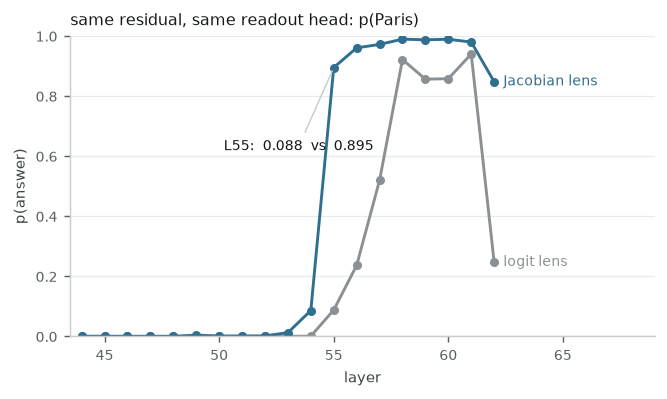

logit    0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.001 0.088 0.237 0.520 0.922 0.856 0.858 
0.940 0.247

jacobian 0.000 0.000 0.000 0.000 0.000 0.004 0.001 0.001 0.001 0.012 0.086 0.895 0.961 0.972 0.990 0.987 0.989 
0.980 0.848

top-1 becomes ' Paris' at L55 (jacobian) and L55 (logit)

p(answer) passes 0.5 at L55 (jacobian) and L57 (logit)

at L55: 0.088 vs 0.895, at L62: 0.247 vs 0.848

In [12]:
jacobian_probability, jacobian_top_token = [], []
for layer_index in LAYERS:
    scores = readout(transport(residual_by_layer[layer_index][0, last_position],
                               layer_index)).astype(mx.float32)
    jacobian_probability.append(float(mx.softmax(scores)[answer_token]))
    jacobian_top_token.append(tokenizer.decode([int(mx.argmax(scores))]))

figure, axes = plt.subplots(figsize=(5.8, 3.0))
axes.plot(LAYERS, logit_probability, color=LOGIT_COLOR, marker="o")
axes.plot(LAYERS, jacobian_probability, color=JACOBIAN_COLOR, marker="o")
axes.text(LAYERS[-1] + 0.4, logit_probability[-1], "logit lens",
          color=LOGIT_COLOR, va="center", fontsize=8)
axes.text(LAYERS[-1] + 0.4, jacobian_probability[-1], "Jacobian lens",
          color=JACOBIAN_COLOR, va="center", fontsize=8)
index_of_55 = LAYERS.index(55)
axes.annotate(f"L55:  {logit_probability[index_of_55]:.3f}"
              f"  vs  {jacobian_probability[index_of_55]:.3f}",
              xy=(55, jacobian_probability[index_of_55]), xytext=(50.2, 0.62),
              color=INK, fontsize=8,
              arrowprops=dict(arrowstyle="-", color="#c8cccd", lw=0.8))
axes.set_xlim(43.5, 69)
panel(axes, f"same residual, same readout head: p({ANSWER.strip()})", "layer",
      "p(answer)", 1.0)
plt.show()

print("  logit    " + " ".join(f"{p:.3f}" for p in logit_probability))
print("  jacobian " + " ".join(f"{p:.3f}" for p in jacobian_probability))
print(f"  top-1 becomes {ANSWER!r} at "
      f"L{first_layer_where(jacobian_top_token, lambda t: t == ANSWER)} "
      f"(jacobian) and L{logit_top_layer} (logit)")
print(f"  p(answer) passes 0.5 at "
      f"L{first_layer_where(jacobian_probability, lambda p: p > 0.5)} "
      f"(jacobian) and "
      f"L{first_layer_where(logit_probability, lambda p: p > 0.5)} (logit)")
print(f"  at L55: {logit_probability[index_of_55]:.3f} vs "
      f"{jacobian_probability[index_of_55]:.3f}, "
      f"at L62: {logit_probability[-1]:.3f} vs {jacobian_probability[-1]:.3f}")

### 讀出來的

同一個 residual、同一個讀出頭,兩把尺在中段給出的機率差一個數量級,機率過半的層數差
兩層。top-1 翻成 `' Paris'` 的層數兩者相同,所以這個例子的差距在信心。換個語言問同一
件事,層數的差距會拉開很多,附錄 D。

$\ell$ 越靠後,$J_\ell$ 越接近單位矩陣,兩把尺應該收在一起。圖的尾端兩條還是分開的,
因為釋出的 lens 平均過,跟這一句自己的 $J$ 有距離,附錄 C 量的就是這個距離。

$J$ 是某一個輸入、某一個位置附近的一階近似,換個 prompt 就是另一個 $J$,而平均會抹掉
個別 prompt 的結構。讀得到也不代表模型在用它,要證明因果得動手去改,那是完整版
§6 和 §7 的事。

## 附錄

### A. 整個 $J$ 怎麼算,以及 forward-mode 為什麼不通

cotangent 換成 one-hot $e_i$,反向傳播給的就是 $J$ 的第 $i$ 列。要整個 $J$ 就是 5120 個
one-hot,一次批 64 個的話 80 批。訓練時的 `loss.backward()` 是同一個呼叫,cotangent 放
的是 1.0。

釋出的 lens 對位置取平均,算的是
$\mathbb{E}_{t' \le t}\big[\partial h_{L,t} / \partial h_{\ell,t'}\big]$,
並且跳過前 16 個位置(BOS 和格式 token,讀出那裡是雜訊)。

$J h$ 是矩陣乘向量,理論上 forward-mode 微分一次就給,不必湊矩陣也不必下載。這條路
在 MLX 上不通,因為 fast RMSNorm、RoPE、attention 都是 `CustomKernel`,只寫了
reverse 規則,
`mx.jvp` 會直接丟 `[Primitive::jvp] Not implemented for CustomKernel`。

In [13]:
SKIP_FIRST_POSITIONS = 16


def jacobian_rows(ids, source_layer, row_count):
    """The first row_count rows of J, averaged over positions the way the lens was."""
    sequence_length = ids.shape[1]
    valid_positions = mx.array(
        list(range(SKIP_FIRST_POSITIONS, sequence_length - 1)), dtype=mx.int32)
    one_hot = (mx.arange(hidden_size)[None, :]
               == mx.arange(row_count)[:, None]).astype(mx.float32)
    position_mask = (mx.arange(sequence_length)[None, :]
                     == valid_positions[:, None]).any(axis=0).astype(mx.float32)
    cotangent = (one_hot[:, None, :] * position_mask[None, :, None]).astype(model_dtype)
    delta = mx.zeros((row_count, sequence_length, hidden_size), dtype=model_dtype)
    set_linear_attention_train(True)
    with no_async_eval():
        (_,), (gradient,) = mx.vjp(
            lambda perturbation: forward_from(ids, perturbation, source_layer),
            (delta,), (cotangent,))
        rows = mx.take(gradient, valid_positions, axis=1).mean(axis=1).astype(mx.float32)
        mx.eval(rows)
    set_linear_attention_train(False)
    return rows


long_prompt = ("The history of the Roman Empire spans several centuries and includes "
               "many emperors, wars, and cultural achievements that shaped the "
               "ancient world.")

start = time.perf_counter()
computed_rows = jacobian_rows(
    mx.array(tokenizer.encode(long_prompt)[:48])[None], 54, 64)
elapsed = time.perf_counter() - start
computed_flat = computed_rows.reshape(-1)
released_flat = released_lens[54].astype(mx.float32)[:64].reshape(-1)

print(f"J[L54] first 64 of {hidden_size} rows: {tuple(computed_rows.shape)} in "
      f"{elapsed:.0f}s  ->  whole matrix about "
      f"{elapsed * hidden_size / 64 / 60:.0f} min per layer")
print(f"diagonal J[0,0] = {float(computed_rows[0, 0]):.3f}   "
      f"row norm = {float(mx.linalg.norm(computed_rows[0])):.3f}")
print(f"cosine(these rows, released lens) = "
      f"{float((computed_flat @ released_flat) / (mx.linalg.norm(computed_flat) * mx.linalg.norm(released_flat))):.3f}")

J[L54] first 64 of 5120 rows: (64, 5120) in 23s  ->  whole matrix about 31 min per layer

diagonal J[0,0] = 0.949   row norm = 1.136

cosine(these rows, released lens) = 0.893

### B. 沒有那 3.1 GB 也能跑

要的是名次而不是機率的話,反向傳播就夠。候選集取模型最後一層的 top-8,每一層做一次
批次 VJP 拿到這 8 個 token 的尺,看答案排第幾。名次對 $1/\mathrm{rms}(Jh)$ 那個純量
免疫 —— 分母是同一個正數,不影響排序。

現算的那條比釋出的更早把答案排到第一。局部的 $J$ 只描述這一句,沒有被一千個 prompt
的平均稀釋,這能解釋它為什麼更早。單一 prompt、單一位置的排名也更容易是雜訊,而這張
圖分不出是哪一種。

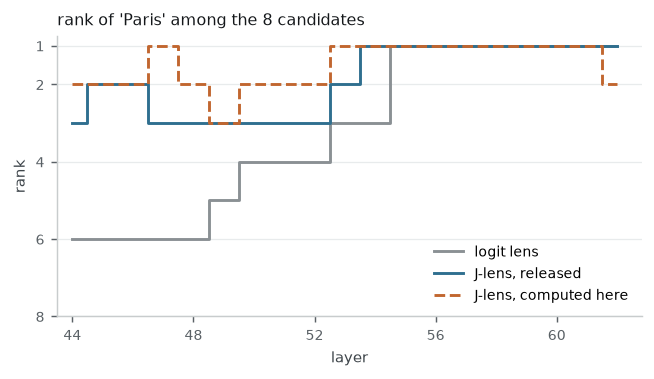

candidates: [' Paris', ' not', '\n\n', ' London', ' the', ' a', ' __', ' Berlin']

whole curve, 19 layers, no released lens: 42s

logit     reaches rank 1 at L55

released  reaches rank 1 at L54

computed  reaches rank 1 at L47

In [14]:
CANDIDATES = [int(token) for token in mx.argsort(
    -readout(residual_by_layer[-1])[0, last_position].astype(mx.float32))[:8].tolist()]
candidate_cotangents = mx.stack(
    [unembed_row(token) * gamma for token in CANDIDATES], axis=0)


def rank_computed_here(layer_index):
    """Rank of the answer among CANDIDATES, from one batched backward pass."""
    cotangent = mx.zeros((8, ids.shape[1], hidden_size), dtype=mx.float32)
    cotangent[:, last_position, :] = candidate_cotangents
    delta = mx.zeros((8, ids.shape[1], hidden_size), dtype=model_dtype)
    set_linear_attention_train(True)
    with no_async_eval():
        (_,), (gradient,) = mx.vjp(
            lambda perturbation: forward_from(ids, perturbation, layer_index),
            (delta,), (cotangent.astype(model_dtype),))
        scores = (gradient[:, last_position, :].astype(mx.float32)
                  @ residual_by_layer[layer_index][0, last_position].astype(mx.float32))
        mx.eval(scores)
    set_linear_attention_train(False)
    return 1 + int(mx.sum(scores > scores[0]))


def rank_among_candidates(all_scores):
    scores = all_scores[mx.array(CANDIDATES)]
    return 1 + int(mx.sum(scores > scores[0]))


start = time.perf_counter()
rank_computed, rank_released, rank_logit = [], [], []
for layer_index in LAYERS:
    h = residual_by_layer[layer_index][0, last_position]
    rank_computed.append(rank_computed_here(layer_index))
    rank_released.append(
        rank_among_candidates(readout(transport(h, layer_index)).astype(mx.float32)))
    rank_logit.append(rank_among_candidates(readout(h).astype(mx.float32)))
elapsed = time.perf_counter() - start

figure, axes = plt.subplots(figsize=(5.8, 2.8))
# all three converge on rank 1, so end labels would sit on top of each other
axes.step(LAYERS, rank_logit, where="mid", color=LOGIT_COLOR, label="logit lens")
axes.step(LAYERS, rank_released, where="mid", color=JACOBIAN_COLOR,
          label="J-lens, released")
axes.step(LAYERS, rank_computed, where="mid", color=COMPUTED_COLOR, ls="--",
          label="J-lens, computed here")
axes.invert_yaxis()
axes.set_yticks([1, 2, 4, 6, 8])
axes.set_xlim(43.5, 62.8)
axes.set_xticks(range(44, 63, 4))
axes.legend(loc="lower right")
panel(axes, f"rank of {ANSWER.strip()!r} among the 8 candidates", "layer", "rank")
plt.show()

print(f"candidates: {[tokenizer.decode([token]) for token in CANDIDATES]}")
print(f"whole curve, {len(LAYERS)} layers, no released lens: {elapsed:.0f}s")
for name, ranks in (("logit", rank_logit), ("released", rank_released),
                    ("computed", rank_computed)):
    first_layer = next((layer for layer, rank in zip(LAYERS, ranks) if rank == 1), None)
    print(f"  {name:<9} reaches rank 1 at L{first_layer}")

### C. 現算的尺跟釋出的差在哪

釋出的 lens 對位置平均過。把現算的也照同樣方式平均,cosine 就跳上來,第 3 節那個偏低的
cosine 來自條件不同。

短 prompt 沒辦法做這件事,5 個 token 裡位置 $\ge 16$ 的一個都沒有。前面墊一段無關的文字
之後才有位置可平均。

In [15]:
FILLER = ("Here are some notes about geography that provide background context "
          "for the question that follows this introductory sentence. ")


def ruler_averaged(token, layer_index, ids):
    """The same ruler, averaged over positions the way the released lens was fitted."""
    sequence_length = ids.shape[1]
    valid_positions = mx.array(
        list(range(SKIP_FIRST_POSITIONS, sequence_length - 1)), dtype=mx.int32)
    position_mask = (mx.arange(sequence_length)[None, :]
                     == valid_positions[:, None]).any(axis=0).astype(mx.float32)
    cotangent_row = unembed_row(token) * gamma
    cotangent = (cotangent_row[None, :] * position_mask[:, None])[None].astype(model_dtype)
    delta = mx.zeros((1, sequence_length, hidden_size), dtype=model_dtype)
    set_linear_attention_train(True)
    with no_async_eval():
        (_,), (gradient,) = mx.vjp(
            lambda perturbation: forward_from(ids, perturbation, layer_index),
            (delta,), (cotangent,))
        v = mx.take(gradient[0], valid_positions, axis=0).mean(axis=0).astype(mx.float32)
        mx.eval(v)
    set_linear_attention_train(False)
    return v


CHECK_LAYERS = [54, 58, 62]
print(f"cosine(computed here, released), for {ANSWER!r}")
print(f"{'prompt':<8} {'tokens':>7} {'averaged':>9} "
      + " ".join(f"{'L' + str(layer):>8}" for layer in CHECK_LAYERS))
for label, text in (("short", prompt), ("padded", FILLER + prompt)):
    prompt_ids = encode(text)
    for averaged in (False, True):
        if averaged and prompt_ids.shape[1] <= SKIP_FIRST_POSITIONS + 1:
            print(f"{label:<8} {prompt_ids.shape[1]:>7} {'yes':>9}   "
                  f"no position >= {SKIP_FIRST_POSITIONS} to average over")
            continue
        cosines = []
        for layer in CHECK_LAYERS:
            v = (ruler_averaged(answer_token, layer, prompt_ids) if averaged
                 else ruler(answer_token, layer, prompt_ids,
                            prompt_ids.shape[1] - 1))
            released = (unembed_row(answer_token) * gamma) @ released_lens[layer].astype(
                mx.float32)
            cosines.append(float(v @ released
                                 / (mx.linalg.norm(v) * mx.linalg.norm(released))))
        print(f"{label:<8} {prompt_ids.shape[1]:>7} "
              f"{'yes' if averaged else 'no':>9} "
              + " ".join(f"{value:>8.3f}" for value in cosines))

cosine(computed here, released), for ' Paris'

prompt    tokens  averaged      L54      L58      L62

short          5        no    0.337    0.340    0.729

short          5       yes   no position >= 16 to average over

padded        24        no    0.320    0.338    0.717

padded        24       yes    0.835    0.882    0.974

### D. 論文其餘的結果

完整版把論文的實驗都在 Qwen3.6-27B-4bit 上跑了一遍。這裡只記結論和關鍵數字,圖和程式碼
在[完整版](jacobian_lens_full.ipynb)對應的節。

#### 讀出的結果

| 問題 | 結果 | 節 |
|---|---|---|
| 換個語言問同一件事 | 中文 `法国的首都是`,J-lens 在 L23 就讀到 `' Paris'`,logit lens 要到 L58,早 35 層。法文早 36 層、日文早 17 層,英文只早 1 層 | §4 |
| J-space 佔 residual 多少 | 25 個 token 方向的非負組合,L60 解釋 8.1%,隨機 25 個方向只有 0.0%。25 個係數裡只有 12 個非零,同一個詞的不同拼法最後只留一個 | §5 |

#### 介入的結果

| 面向 | 做法 | 數字 | 成立 |
|---|---|---|---|
| 概念交換 | France 換成 China,四個問題同一個介入 | 首都 `' Paris'` → `' Beijing'`、語言 → `' Chinese'`、洲 → `' Asia'`、貨幣 → `' yuan'` | 成立 |
| 定向調節 | 叫它想 / 叫它不要想白熊 | 沒提到時 0.0001,叫它想 0.0075,叫它不要想反而 0.1079 | 成立,抑制無效 |
| 概念消除 | 投影掉 France、French、Paris 整個 span | p(Paris) 0.617 → 0.001,top-1 變成 `' not'`。一個一個減不夠,要整個 span 一起 | 成立 |
| 選擇性 | 明確報告語言 vs 只要求延續語言 | 明確報告在 alpha=1.5 翻成法文(0.003 / 0.131);只要求延續的那組沒翻成法文,直接壞掉 | 部分 |
| 口頭報告 | 注入 volcano,問它在想什麼 | alpha=0.5 就答 `' volcano'`,但無關的 prompt 也一樣會說 | 成立但不專一 |
| 內部推理 | spider 換成 ant,會不會改算腳數 | 數腳沒改(p(8) 0.124 → 0.083)。艾菲爾鐵塔那題改在內容位置就成立,`' Paris'` → `' Beijing'` 0.189 | 兩跳成立,數腳不成立 |

介入要落在內容的位置,而且通常要一整段位置。只改最後一個位置的話,
模型會直接把換進去的概念講出來(艾菲爾鐵塔那題 p(France)=0.975),推理那一步
沒有發生。

### 參考

[Anthropic 的原文](https://www.anthropic.com/research/global-workspace) ·
[jlens-qwen36](https://github.com/WeZZard/jlens-qwen36)(釋出的 lens)